# Comparing page-layout symmetry across two different kinds of inventory

[`page-layout-clustering-demo.ipynb`](page-layout-clustering-demo.ipynb) clusters pages within a
single inventory number by their text-line layout. This notebook asks whether the verso and
recto halves of a two-page opening tend to land in the *same* layout cluster or in *different*
ones, and whether that depends on what kind of document the inventory contains:

- **`NL-HaNA_2.10.50_1`** is a resolutions register where many openings lay out a single table
  *across* the full two-page spread -- the verso half can be laid out differently from the recto
  half (e.g. row labels/dates vs. data columns), so their page-layout clusters might differ.
- **`NL-AsnDA_0114.11_1`** is a notary deeds register where body text runs continuously across
  the gutter -- a deed's layout doesn't change depending on which half of the spread it falls on,
  so verso and recto pages of the same opening should usually land in the same layout cluster.

We cluster pages for both inventories independently with
`archival_structures.analysis.page_layout_clustering`, then check, for every opening, whether its
verso and recto pages share a cluster label.

In [1]:
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    is_opening, get_opening_features, compute_corpus_median_width, split_scan,
)
from archival_structures.analysis.page_layout_clustering import cluster_page_layouts

CORPORA = {
    'NL-HaNA_2.10.50_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'thumb_dir': Path('../../data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'label': 'table register',
    },
    'NL-AsnDA_0114.11_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'thumb_dir': Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'label': 'notary deeds',
    },
}
for info in CORPORA.values():
    assert info['pagexml_dir'].exists(), info['pagexml_dir']
    assert info['thumb_dir'].exists(), info['thumb_dir']

## Loading and splitting each corpus into pages

As in the line-clustering comparison notebook, the two corpora need different splitting
strategies: `NL-HaNA_2.10.50_1`'s single-page covers are a large enough share of the corpus for
`classify_inventory_structure` to recognise as a structural width group, but
`NL-AsnDA_0114.11_1`'s covers (2 out of 630 scans) are not -- so its splitting is driven directly
by the per-scan `is_opening` heuristic instead. See that notebook for the full explanation.

`GridPattern` (which `cluster_page_layouts` relies on) degenerates to all-noise on pages with
zero lines, so those are filtered out after splitting, same as in the single-corpus demo.

In [2]:
def load_scans(pagexml_dir, n=60):
    xml_paths = sorted(Path(pagexml_dir).glob('*.xml'))[:n]
    return [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_paths]


def split_via_width_groups(scans):
    structure = classify_inventory_structure(scans)
    print(f"  structure: {structure.structure_type} {structure.type_counts}")
    return split_inventory_into_pages(scans, structure=structure)


def split_via_gap_heuristic(scans):
    median_width = compute_corpus_median_width(scans)
    pages = []
    n_opening = 0
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_width):
            features = get_opening_features(scan, corpus_median_width=median_width)
            verso, recto = split_scan(scan, features.separation_point)
            pages += [verso, recto]
            n_opening += 1
        else:
            pages.append(scan)
    print(f"  {n_opening}/{len(scans)} scans detected as openings (gap heuristic)")
    return pages


for inv_num, info in CORPORA.items():
    print(inv_num)
    info['scans'] = load_scans(info['pagexml_dir'])
    info['scans_by_id'] = {scan.id: scan for scan in info['scans']}
    split_fn = split_via_width_groups if inv_num == 'NL-HaNA_2.10.50_1' else split_via_gap_heuristic
    all_pages = split_fn(info['scans'])
    info['pages'] = [page for page in all_pages if len(page.get_lines()) > 0]
    info['page_by_id'] = {page.id: page for page in info['pages']}
    print(f"  {len(info['scans'])} scans -> {len(all_pages)} pages -> "
          f"{len(info['pages'])} with at least one line")

NL-HaNA_2.10.50_1
  structure: book_of_openings {'opening': 45, 'single_page': 14, 'odd_shaped': 1}
  60 scans -> 105 pages -> 100 with at least one line
NL-AsnDA_0114.11_1
  59/60 scans detected as openings (gap heuristic)
  60 scans -> 119 pages -> 96 with at least one line


## Cluster page layouts independently per corpus

As with the line-clustering comparison, each corpus gets its own HDBSCAN run over its own
`GridPattern` TF-IDF vectors -- cluster labels are corpus-specific.

In [3]:
for inv_num, info in CORPORA.items():
    clusters, grid_pattern = cluster_page_layouts(info['pages'], unit_size=50, pattern_size=3,
                                                   min_cluster_size=4)
    info['clusters'] = clusters
    info['grid_pattern'] = grid_pattern
    n_clusters = clusters.nunique() - (1 if -1 in clusters.values else 0)
    print(f"{inv_num} ({info['label']}): {len(info['pages'])} pages, {n_clusters} clusters, "
          f"{(clusters == -1).mean():.0%} noise")
    print(clusters.value_counts().sort_index())
    print()

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 100 docs, with 100 x and 119 y points
took 0.1 seconds (total: 0.1)
done computing patterns, 387 distinct patterns
took 1.2 seconds (total: 1.3)
done computing tf-idf of patterns
took 0.0 seconds (total: 1.3)
NL-HaNA_2.10.50_1 (table register): 100 pages, 2 clusters, 83% noise
cluster
-1    83
 0     7
 1    10
Name: count, dtype: int64

done setting base grid points
took 0.0 seconds (total: 0.0)
done setting line grid_points for 96 docs, with 54 x and 81 y points
took 0.0 seconds (total: 0.0)
done computing patterns, 417 distinct patterns
took 0.4 seconds (total: 0.4)
done computing tf-idf of patterns
took 0.0 seconds (total: 0.5)
NL-AsnDA_0114.11_1 (notary deeds): 96 pages, 2 clusters, 43% noise
cluster
-1    41
 0    42
 1    13
Name: count, dtype: int64



## Measuring verso/recto symmetry

For every opening with both a verso and a recto page assigned to a (non-noise) cluster, check
whether they were assigned the *same* cluster. This is a direct, binary version of the
per-opening Jaccard score used in the line-clustering comparison -- appropriate here since each
page gets exactly one cluster label rather than a set of line-cluster labels.

In [4]:
def same_cluster_pair_rate(info):
    clusters = info['clusters']
    verso_ids = [page.id for page in info['pages'] if page.id.endswith('-verso')]
    matches, total = 0, 0
    for verso_id in verso_ids:
        recto_id = verso_id.replace('-verso', '-recto')
        if recto_id in clusters.index and clusters[verso_id] != -1 and clusters[recto_id] != -1:
            total += 1
            if clusters[verso_id] == clusters[recto_id]:
                matches += 1
    return matches, total


for inv_num, info in CORPORA.items():
    matches, total = same_cluster_pair_rate(info)
    rate = matches / total if total else float('nan')
    print(f"{inv_num} ({info['label']}): same-cluster verso/recto pairs: {matches}/{total} ({rate:.0%})")

NL-HaNA_2.10.50_1 (table register): same-cluster verso/recto pairs: 0/1 (0%)
NL-AsnDA_0114.11_1 (notary deeds): same-cluster verso/recto pairs: 17/18 (94%)


## Visual comparison

Each page's line outlines are drawn on its real thumbnail. Compare an example verso/recto pair
from each corpus -- in the table register, look for differences in column/row structure between
the two halves; in the notary deeds, the two halves should look like the same kind of page.

In [5]:
def original_scan_id(page_id):
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id


def find_thumbnail(thumb_dir, scan_id):
    """Locate `scan_id`'s thumbnail regardless of naming convention (e.g. `<scan_id>` directly
    for NL-HaNA, `thumb-width_300-scan-<stem>.jp2.png` for NL-AsnDA) by matching on the scan's
    filename stem."""
    stem = Path(scan_id).stem
    return next(Path(thumb_dir).glob(f'*{stem}*'))


def page_thumbnail(page, info):
    scan_id = original_scan_id(page.id)
    image = Image.open(find_thumbnail(info['thumb_dir'], scan_id)).convert('RGB')
    if page.id == scan_id:
        return image
    scan = info['scans_by_id'][scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))


def draw_page_outline(page, info):
    image = page_thumbnail(page, info).copy()
    scale = image.width / page.coords.width
    draw = ImageDraw.Draw(image)
    for line in page.get_lines():
        x, y = line.coords.left * scale, line.coords.top * scale
        w, h = line.coords.width * scale, line.coords.height * scale
        draw.rectangle([x, y, x + w, y + h], outline='red', width=1)
    return image


def show_example_opening(info):
    verso = next(page for page in info['pages']
                 if page.id.endswith('-verso') and info['clusters'][page.id] != -1)
    recto = info['page_by_id'][verso.id.replace('-verso', '-recto')]
    print(f"verso cluster: {info['clusters'][verso.id]}, recto cluster: {info['clusters'][recto.id]}")
    verso_im = draw_page_outline(verso, info)
    recto_im = draw_page_outline(recto, info)
    combined = Image.new('RGB', (verso_im.width + recto_im.width + 10,
                                 max(verso_im.height, recto_im.height)), 'white')
    combined.paste(verso_im, (0, 0))
    combined.paste(recto_im, (verso_im.width + 10, 0))
    return combined

verso cluster: 0, recto cluster: -1


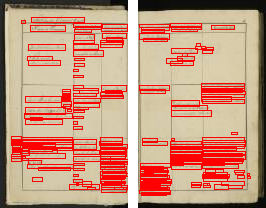

In [6]:
show_example_opening(CORPORA['NL-HaNA_2.10.50_1'])

verso cluster: 0, recto cluster: 0


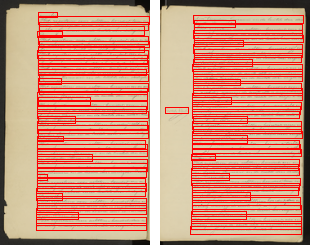

In [7]:
show_example_opening(CORPORA['NL-AsnDA_0114.11_1'])

## Summary

The two corpora behave very differently:

- `NL-HaNA_2.10.50_1` (table register): clustering finds almost no recurring whole-page layout
  (83% noise) and the one verso/recto pair that did land in non-noise clusters ended up in
  *different* clusters.
- `NL-AsnDA_0114.11_1` (notary deeds): clustering finds a much cleaner two-cluster structure
  (only 43% noise), and 17 out of 18 verso/recto pairs land in the *same* cluster.

This matches the structural expectation from the line-clustering comparison: a notary deed's
page layout doesn't depend on which half of the spread it's on, so verso and recto consistently
get the same layout label. A table register's two halves can serve different roles within the
same table (labels vs. data, for instance), so their page layouts are much less likely to match
-- and the table's layout is also less internally consistent across different openings to begin
with, which is why so much of it ends up as noise rather than forming clusters at all.